# 머신러닝 모델 뭘로 정하지?

## 선형? 비선형?
- Logistic regression, Linear Regression(선형회귀) -> 선형
- 앙상블 모델, SVM(kernel사용)

## Parametric Models vs Non-parametric Models
- 모델의 파라미터 수가 데이터 크기와 무관하게 고정되어져 있는 경우 -> Parametric Models
- 데이터에 따라 달라지는 경우 -> Non-Parametric Models (보통 트리기반 모델) -> 전처리에 있어서 자유로운 부분이 있다
## Tree-based Models
## Probabilistic Models
## Neural Network Models

# 실무적으로 비선형 트리기반 모델이 짱이다 -> 앙상블 트리기반 모델이 짱이다

# 라이브러리 준비

In [51]:
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score


# 1. Train / Test만 나누고 평가

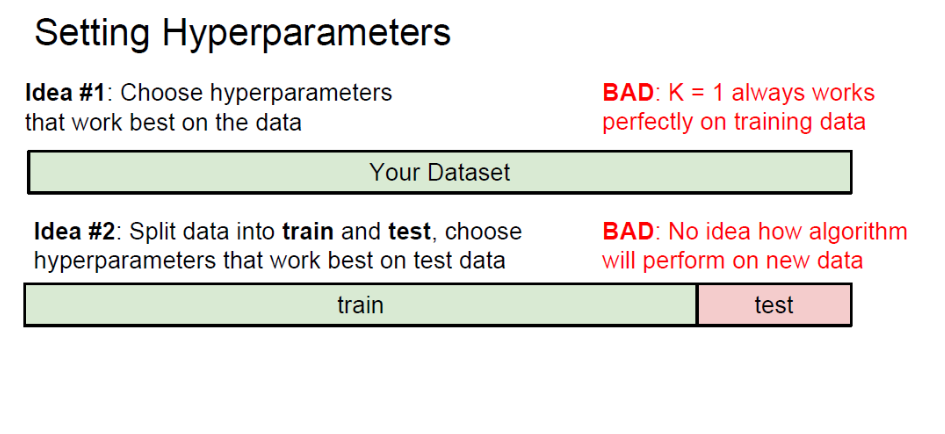

In [54]:
X.shape #-> 행렬 -> Bold -> 크게 쓴다

(569, 30)

In [55]:

y.shape #-> 벡터 -> Italic -> 갸냘프게 기울여

(569,)

In [50]:
# 1) 데이터 로드
data = load_breast_cancer()
X = data.data
y = data.target

# 2) Train / Test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3) 모델 학습
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# 4) 평가
## 참고! 평가할 때 score를 쓸 수 있지만 분류인경우 Accuracy, 회귀인 경우 R2 square로 정해져 있음
## 더 다양한걸 쓰고 싶으면 아래와 같이 직접 sklearn에서 평가지표 계산하는 함수를 가져올 수 있음
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9122807017543859


In [42]:
# 참고로, 과적합인지 발견하려면 train 성능과 test 성능을 비교
train_pred = clf.predict(X_train)
print("Accuracy:", accuracy_score(y_train, train_pred))

Accuracy: 1.0


# 2. Train / Valid / Test로 나눠서 평가
- 핵심: Train에서 Valid를 다시 떼어냄 (Test는 끝까지 손대지 않기)

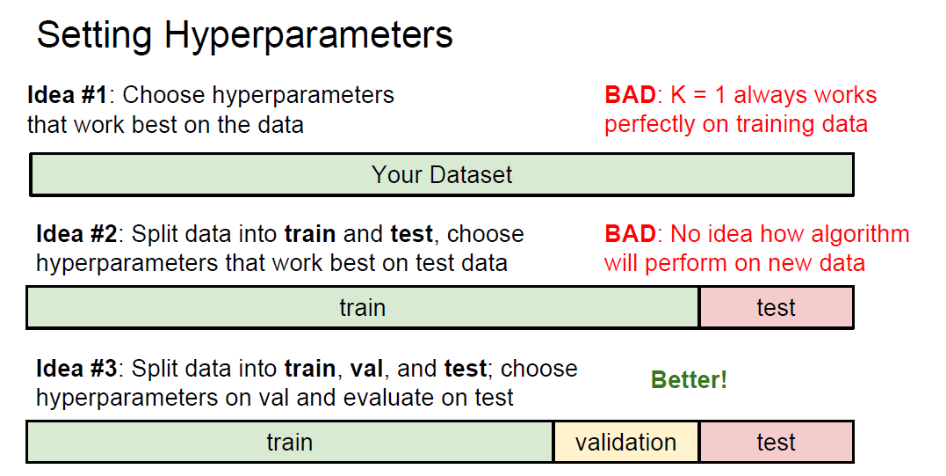

In [43]:
# 1) 데이터 로드
data = load_breast_cancer()
X = data.data
y = data.target

# 2) Train+Valid / Test 분리
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3) Train / Valid 분리
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid, test_size=0.2, random_state=42, stratify=y_train_valid
)

# 4) 모델 학습
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# 5) Valid 평가
valid_pred = clf.predict(X_valid)
print("Valid Accuracy:", accuracy_score(y_valid, valid_pred))

# 이제 위 성능 보면서 하이퍼 파라미터 튜닝 진행
# 하이퍼 파라미터 튜닝이 다 끝났으면 마지막으로 test에 대해서 평가 진행

# 6) Test 평가는 마지막에
test_pred = clf.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, test_pred))


Valid Accuracy: 0.945054945054945
Test Accuracy: 0.9473684210526315


# 3. GridSearchCV(그리드서치) 추가해서 “최적 파라미터” 찾기

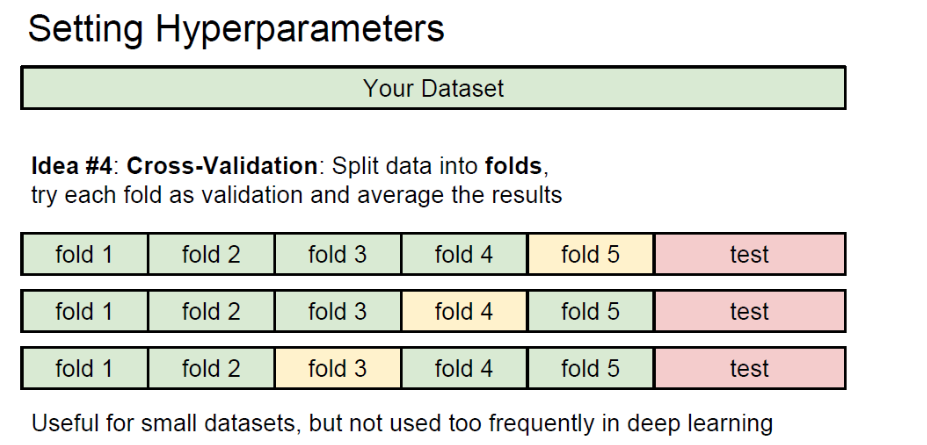

In [47]:
# 1) 데이터 로드
data = load_breast_cancer()
X = data.data
y = data.target

# 2) Train / Test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3) 그리드서치 대상 모델
base_tree = DecisionTreeClassifier(random_state=42)

param_grid = {
    "max_depth": [None, 3, 5, 7, 10],
}

grid = GridSearchCV(
    estimator=base_tree,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1 # 사용가능한 모든 CPU 코어를 사용하겠다
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

# 4) 최적 모델로 Test 평가
best_tree = grid.best_estimator_
y_pred = best_tree.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Best Params: {'max_depth': 5}
Best CV Score: 0.9318681318681318
Test Accuracy: 0.9210526315789473
